## DATA COLLECTION
Step 1: Import Libraries

In [47]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Imbalance
from imblearn.over_sampling import SMOTE

# Save model
import pickle

Step 2: Load Dataset

In [48]:
df = pd.read_csv(r"C:\Vasu\Guvi\EcoType Forest Cover Classification\cover_type.csv")

In [49]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [50]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           145890 non-null  int64
 1   Aspect                              145890 non-null  int64
 2   Slope                               145890 non-null  int64
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64
 6   Hillshade_9am                       145890 non-null  int64
 7   Hillshade_Noon                      145890 non-null  int64
 8   Hillshade_3pm                       145890 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64
 10  Cover_Type                          145890 non-null  str  
 11  Wilderness_Area                     145890 non-null  int64
 12 

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


Check Missing Values

In [51]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64

Check Duplicates

In [52]:
df.duplicated().sum()
df = df.drop_duplicates()
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29


Check Target Distribution

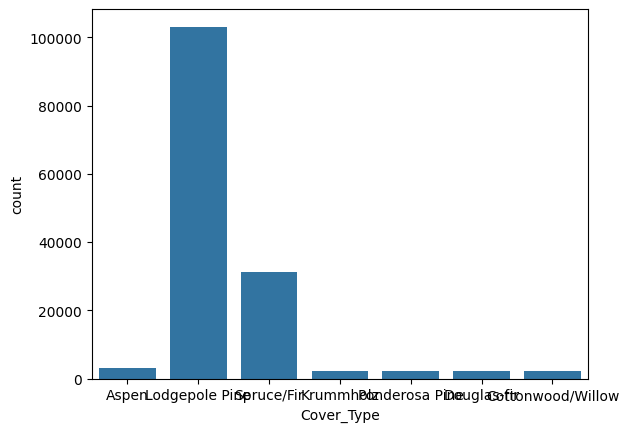

In [53]:
df['Cover_Type'].value_counts()
sns.countplot(x='Cover_Type', data=df)
plt.show()

3️⃣ DATA CLEANING & TRANSFORMATION
Handling Missing Values

If numeric:

In [54]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Cover_Type' in numeric_columns:
    numeric_columns.remove('Cover_Type')

numeric_columns

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points',
 'Wilderness_Area',
 'Soil_Type']

In [55]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

In [56]:
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns

In [57]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X[numeric_columns] = imputer.fit_transform(X[numeric_columns])

In [58]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64

In [59]:
df['Cover_Type'].dtype

<StringDtype(storage='python', na_value=nan)>

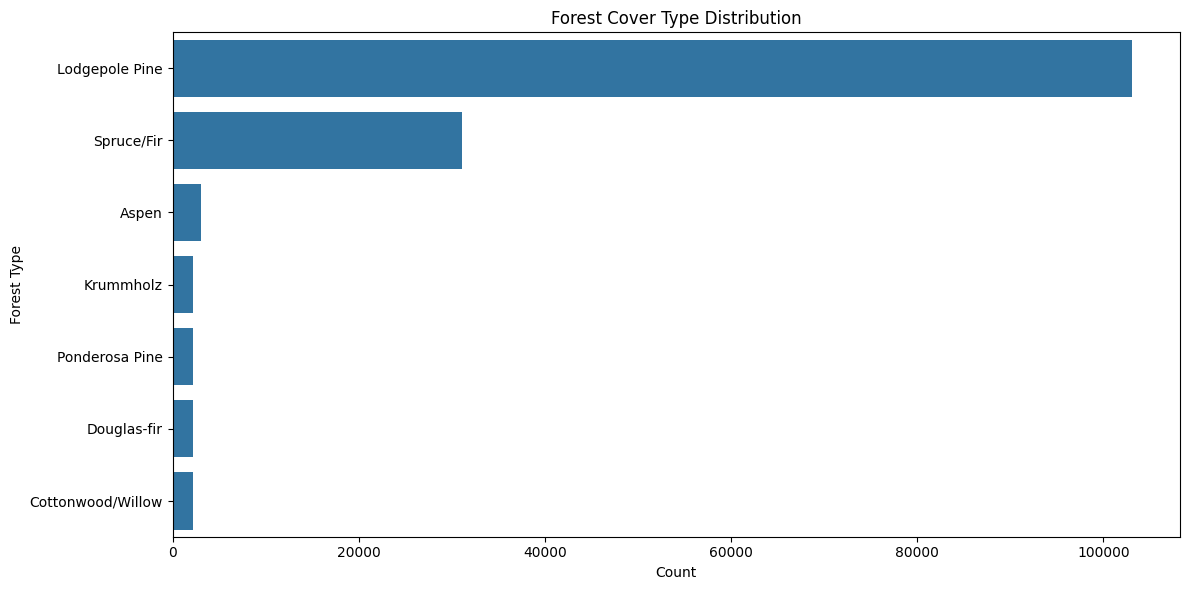

In [60]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Cover_Type',
    data=df,
    order=df['Cover_Type'].value_counts().index
)

plt.title("Forest Cover Type Distribution")
plt.xlabel("Count")
plt.ylabel("Forest Type")
plt.tight_layout()
plt.show()

In [61]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
df['Cover_Type'] = le_target.fit_transform(df['Cover_Type'])

In [62]:
import os

os.makedirs("models", exist_ok=True)

In [63]:
import pickle

pickle.dump(le_target, open("models/target_encoder.pkl", "wb"))

In [64]:

# create folder safely
os.makedirs("models", exist_ok=True)

# save encoder
with open("models/target_encoder.pkl", "wb") as f:
    pickle.dump(le_target, f)

In [65]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64

In [66]:
imputer = SimpleImputer(strategy="median")
df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

In [67]:
df['Soil_Type'].fillna(df['Soil_Type'].mode()[0], inplace=True)

C:\Users\vasug\AppData\Local\Temp\ipykernel_11532\1080442724.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Soil_Type'].fillna(df['Soil_Type'].mode()[0], inplace=True)


0         29.0
1         29.0
2         12.0
3         30.0
4         29.0
          ... 
145885    29.0
145886    29.0
145887    29.0
145888    29.0
145889     1.0
Name: Soil_Type, Length: 145890, dtype: float64

In [68]:
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[numeric_columns] < (Q1 - 1.5 * IQR)) |
          (df[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [69]:
for col in numeric_columns:
    if df[col].skew() > 1:
        df[col] = np.log1p(df[col])


4️⃣ FEATURE ENGINEERING

Encode Categorical Variables

In [70]:
le = LabelEncoder()
df['Wilderness_Area'] = le.fit_transform(df['Wilderness_Area'])
df['Soil_Type'] = le.fit_transform(df['Soil_Type'])

In [71]:
pickle.dump(le, open("models/encoder.pkl", "wb"))

5️⃣ EDA (Exploratory Data Analysis)

Histogram

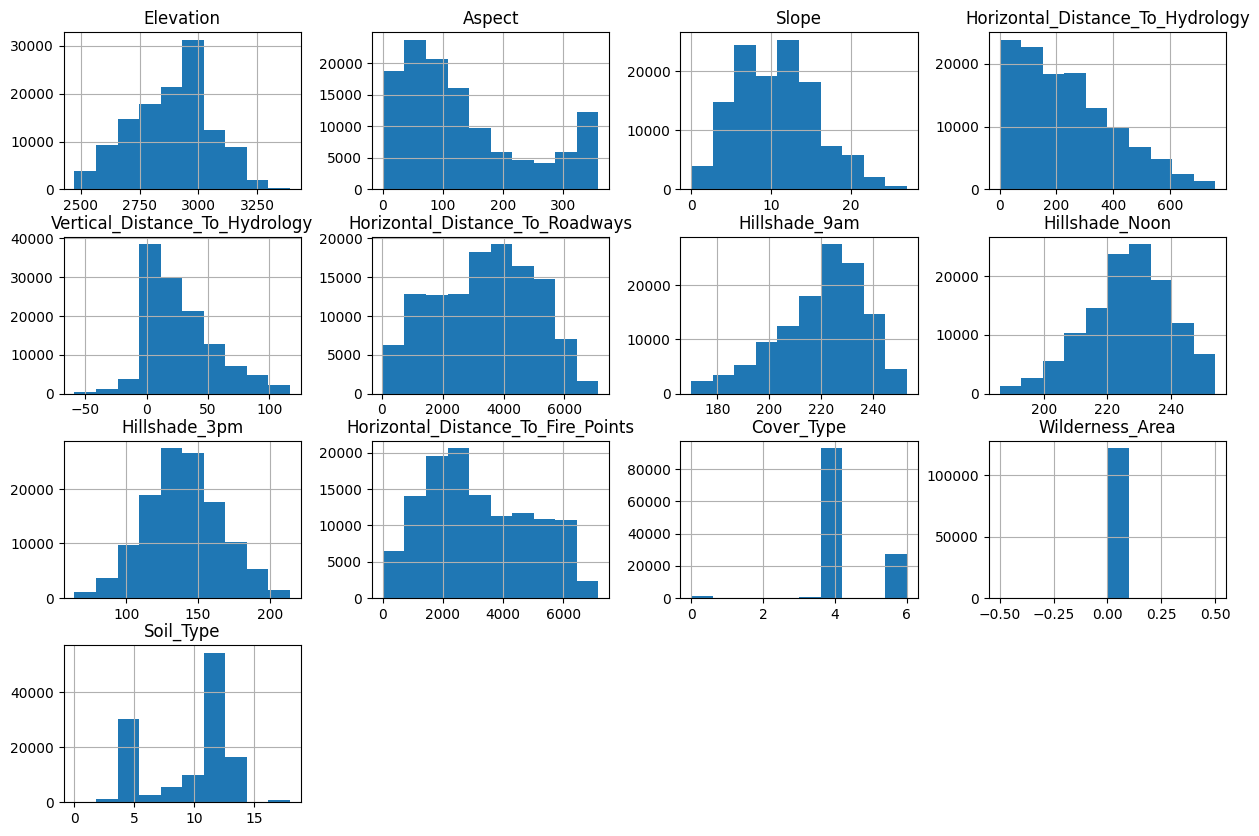

In [72]:
df.hist(figsize=(15,10))
plt.show()

Correlation Heatmap

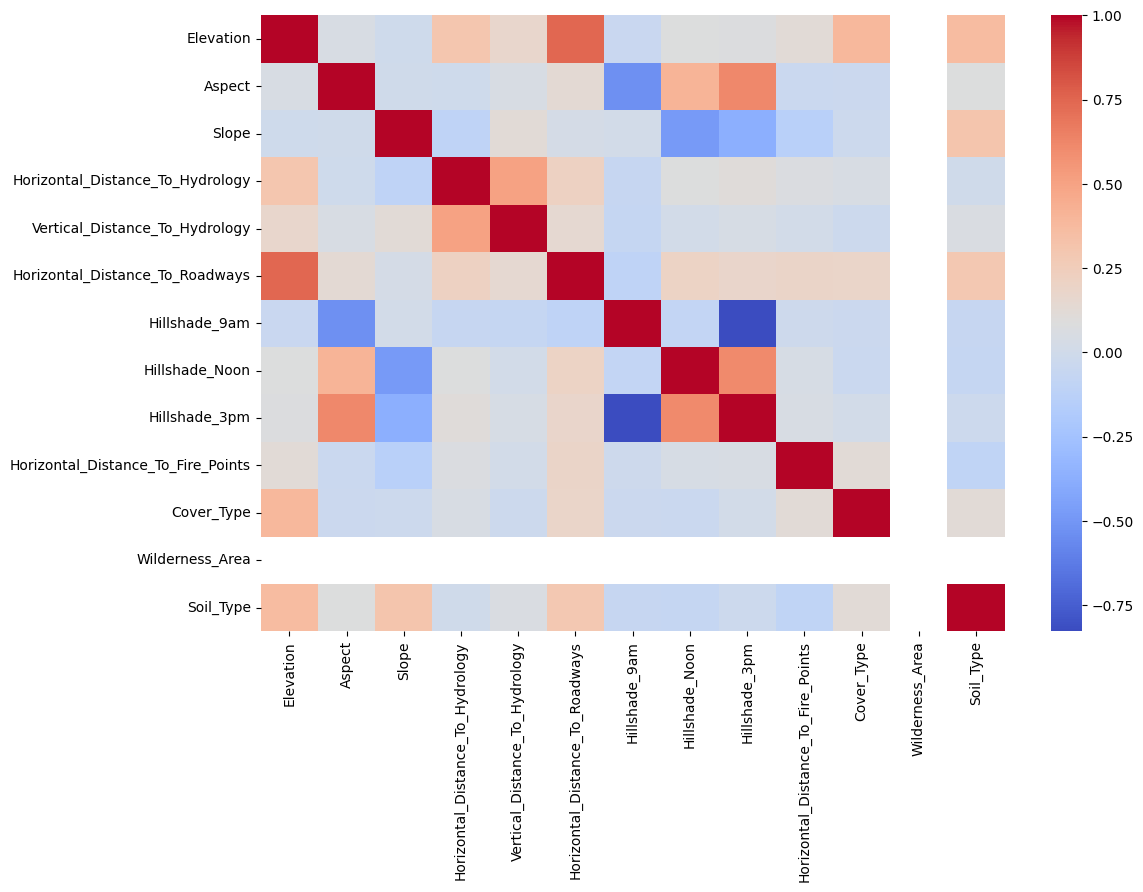

In [73]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

6️⃣ HANDLE CLASS IMBALANCE

In [74]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [75]:
from sklearn.preprocessing import LabelEncoder

le_model = LabelEncoder()
y_resampled = le_model.fit_transform(y_resampled)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [77]:
print(np.unique(y_train))

[0 1 2 3]


7️⃣ FEATURE SELECTION

Using Random Forest Importance

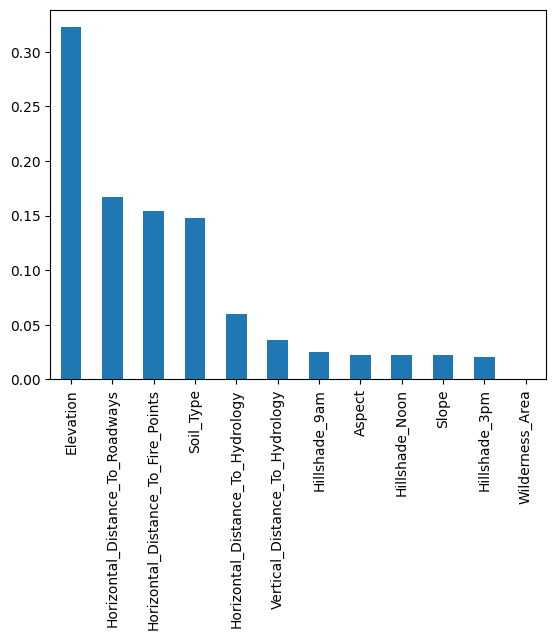

In [78]:
rf = RandomForestClassifier()
rf.fit(X_resampled, y_resampled)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.show()

5 Models Training
1️⃣ Random Forest

In [79]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

2️⃣ Decision Tree

In [80]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

3️⃣ Logistic Regression

In [81]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

c:\Vasu\Guvi\EcoType Forest Cover Classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


4️⃣ KNN

In [82]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [83]:
print("Unique train classes:", np.unique(y_train))
print("Unique test classes:", np.unique(y_test))

Unique train classes: [0 1 2 3]
Unique test classes: [0 1 2 3]


5️⃣ XGBoost

In [84]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

Model Evaluation

In [85]:
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 0.9911577077333046
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18576
           1       1.00      1.00      1.00     18575
           2       0.99      0.98      0.98     18576
           3       0.98      0.99      0.98     18575

    accuracy                           0.99     74302
   macro avg       0.99      0.99      0.99     74302
weighted avg       0.99      0.99      0.99     74302



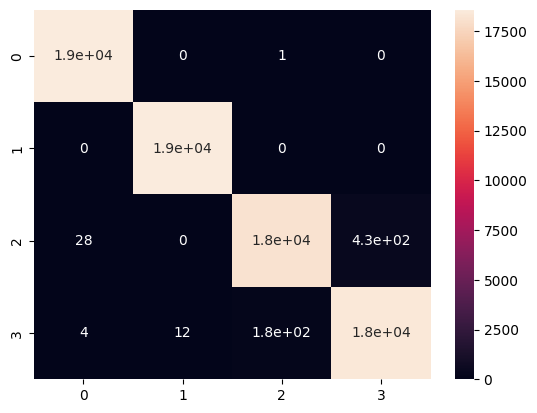

In [86]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True)
plt.show()

Hyperparameter Tuning

Example for Random Forest:

In [87]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100,200],
    'max_depth': [10,20,None],
}

grid = GridSearchCV(RandomForestClassifier(),
                    param_grid=params,
                    cv=3)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

9️⃣ SAVE FINAL MODEL

In [88]:
pickle.dump(best_model, open("models/best_model.pkl", "wb"))

In [90]:
import pickle

feature_names = X.columns.tolist()

with open("models/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

🔟 STREAMLIT APP

In [89]:
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("models/best_model.pkl", "rb"))

st.title("Forest Cover Type Prediction")

elevation = st.number_input("Elevation")
slope = st.number_input("Slope")

if st.button("Predict"):
    input_data = np.array([[elevation, slope, ...]])
    prediction = model.predict(input_data)
    st.success(f"Predicted Cover Type: {prediction[0]}")

ModuleNotFoundError: No module named 'streamlit'